# L2 · Linear regression by gradient descent

**One idea:** fit $\hat y = wx+b$ by descending the MSE gradient, and check that
gradient descent converges to the closed-form least-squares solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# synthetic data: y = 2x + 1 + noise
n = 100
x = np.random.uniform(-3, 3, size=n)
y = 2.0*x + 1.0 + np.random.normal(0, 1.0, size=n)

## 1. Gradient descent
$\mathcal L=\frac1n\sum(y_i-\hat y_i)^2$, with
$\partial\mathcal L/\partial w=-\frac2n\sum(y_i-\hat y_i)x_i$ and
$\partial\mathcal L/\partial b=-\frac2n\sum(y_i-\hat y_i)$.

In [2]:
w, b = 0.0, 0.0
lr = 0.05
losses = []
for step in range(300):
    yhat = w*x + b
    resid = y - yhat
    loss = np.mean(resid**2)
    losses.append(loss)
    gw = -2*np.mean(resid*x)
    gb = -2*np.mean(resid)
    w -= lr*gw
    b -= lr*gb

print(f"GD solution:        w = {w:.4f}, b = {b:.4f}")

GD solution:        w = 1.9895, b = 1.1906


## 2. Compare with the closed-form solution
$\hat\theta = (\tilde X^\top\tilde X)^{-1}\tilde X^\top y$.

In [3]:
X = np.column_stack([x, np.ones_like(x)])          # [x, 1]
theta = np.linalg.solve(X.T @ X, X.T @ y)
print(f"closed-form:        w = {theta[0]:.4f}, b = {theta[1]:.4f}")
print("GD matches closed-form:", np.allclose([w, b], theta, atol=1e-2))

closed-form:        w = 1.9895, b = 1.1906
GD matches closed-form: True


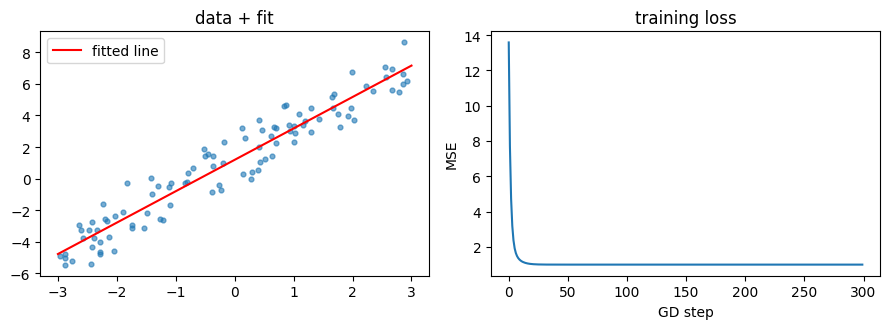

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].scatter(x, y, s=12, alpha=0.6)
xs = np.linspace(-3, 3, 50)
ax[0].plot(xs, w*xs + b, "r", label="fitted line")
ax[0].set_title("data + fit"); ax[0].legend()
ax[1].plot(losses); ax[1].set_xlabel("GD step"); ax[1].set_ylabel("MSE")
ax[1].set_title("training loss")
plt.tight_layout(); plt.show()

## Takeaway
- Linear regression + MSE is Gaussian maximum likelihood, solvable in closed form.
- **Gradient descent reaches the same optimum** — and unlike the closed form it
  scales to the huge, nonlinear models we build next (MLPs).